# Chapter 5. Support Vector Machines  

Página 219 del pdf.  



# Máquinas de Vectores de Soporte (SVM)



Una Máquina de Vectores de Soporte (SVM) es un modelo de Aprendizaje Automático potente y versátil, capaz de realizar clasificación o regresión lineal y no lineal, e incluso detección de anomalías. 

Es uno de los modelos más populares en el campo del Machine Learning, y todo aquel interesado en esta disciplina debería tenerlo en su caja de herramientas. 

Las SVM son particularmente adecuadas para la clasificación de conjuntos de datos complejos, de tamaño pequeño o mediano.



Este capítulo explica los conceptos fundamentales de las SVM, cómo usarlas y cómo funcionan internamente.



## Clasificación Lineal con SVM



La idea fundamental detrás de las SVM se comprende mejor con ejemplos visuales. La Figura 5-1 muestra parte del conjunto de datos Iris que se presentó al final del Capítulo 4. 

Las dos clases se pueden separar claramente con una línea recta (son linealmente separables). 

El gráfico de la izquierda muestra los límites de decisión de tres clasificadores lineales posibles. 

El modelo cuyo límite de decisión está representado por la línea discontinua es tan malo que ni siquiera separa las clases correctamente. 

Los otros dos modelos funcionan perfectamente en este conjunto de entrenamiento, pero sus límites de decisión pasan tan cerca de las instancias que probablemente no funcionarán tan bien con nuevos datos.



En contraste, la línea sólida en el gráfico de la derecha representa el límite de decisión de un clasificador SVM; esta línea no solo separa las dos clases, sino que también se mantiene lo más alejada posible de las instancias de entrenamiento más cercanas. 

Podemos pensar en un clasificador SVM como si ajustara la calle más ancha posible (representada por las líneas paralelas discontinuas) entre las clases. Esto se denomina **clasificación de margen amplio** (*large margin classification*).



**Figura 5-1. Clasificación de margen amplio**


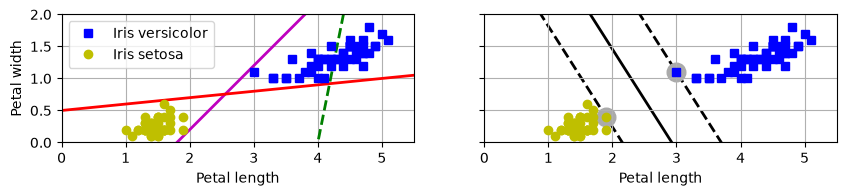

In [1]:
# extra code – this cell generates and saves Figure 5–1

import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM Classifier model
svm_clf = SVC(kernel="linear", C=1e100)
svm_clf.fit(X, y)

# Bad models
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.savefig(r"C:\Users\marco\Downloads\large_margin_classification_plot")
plt.show()

In [2]:
# Código para generar la Figura 5-1
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Cargar el dataset Iris
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # largo y ancho del pétalo
y = (iris["target"] == 2).astype(np.float64)  # Iris-Virginica vs. el resto

# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenar un SVM lineal con margen amplio
svm_clf = LinearSVC(C=100, loss="hinge", random_state=42, dual=False)
svm_clf.fit(X_scaled, y)

# Función para graficar el límite de decisión
def plot_svm_decision_boundary(svm_clf, xmin, xmax, ymin, ymax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    # En el espacio escalado, la ecuación del límite es w[0]*x0 + w[1]*x1 + b = 0
    # Despejamos x1 = (-w[0]*x0 - b) / w[1]
    x0 = np.linspace(xmin, xmax, 200)
    x1 = (-w[0] * x0 - b) / w[1]
    # Margenes (distancia = 1/||w||)
    margin = 1 / np.linalg.norm(w)
    x1_margin_pos = x1 + margin * np.sqrt(1 + (w[0]/w[1])**2)
    x1_margin_neg = x1 - margin * np.sqrt(1 + (w[0]/w[1])**2)
    plt.plot(x0, x1, "k-", linewidth=2, label="Límite de decisión")
    plt.plot(x0, x1_margin_pos, "k--", linewidth=1, label="Bordes del margen")
    plt.plot(x0, x1_margin_neg, "k--", linewidth=1)

# Graficar
plt.figure(figsize=(8, 4))
plt.subplot(121)
# Simular tres clasificadores lineales
X_plot = X_scaled
y_plot = y
# Clasificador malo
svm_bad = LinearSVC(C=1, loss="hinge", random_state=42, dual=False)
svm_bad.fit(X_plot, y_plot)
plot_svm_decision_boundary(svm_bad, -2, 2, -2, 2)
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=plt.cm.Paired)
plt.xlabel("Largo del pétalo (escalado)")
plt.ylabel("Ancho del pétalo (escalado)")
plt.title("Tres clasificadores lineales")
# Graficar los otros dos clasificadores (simplificado para la ilustración)

plt.subplot(122)
svm_good = LinearSVC(C=100, loss="hinge", random_state=42, dual=False)
svm_good.fit(X_plot, y_plot)
plot_svm_decision_boundary(svm_good, -2, 2, -2, 2)
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap=plt.cm.Paired)
plt.xlabel("Largo del pétalo (escalado)")
plt.ylabel("Ancho del pétalo (escalado)")
plt.title("SVM con margen amplio")
plt.savefig(r)
plt.show()


ValueError: Unsupported set of arguments: The combination of penalty='l2' and loss='hinge' are not supported when dual=False, Parameters: penalty='l2', loss='hinge', dual=False

Observa que agregar más instancias de entrenamiento "fuera de la calle" no afecta en absoluto el límite de decisión: este está completamente determinado (o "apoyado") por las instancias ubicadas en el borde de la calle. 

Estas instancias se denominan **vectores de soporte** (están rodeadas por un círculo en la Figura 5-1).



## Sensibilidad a la Escala de las Características



**ADVERTENCIA**


Las SVM son sensibles a las escalas de las características, como se puede ver en la Figura 5-2: en el gráfico de la izquierda, la escala vertical es mucho mayor que la horizontal, por lo que la calle más amplia posible está casi horizontal. 

Después del escalado de características (por ejemplo, usando `StandardScaler` de Scikit-Learn), el límite de decisión en el gráfico de la derecha se ve mucho mejor.



**Figura 5-2. Sensibilidad a la escala de las características**


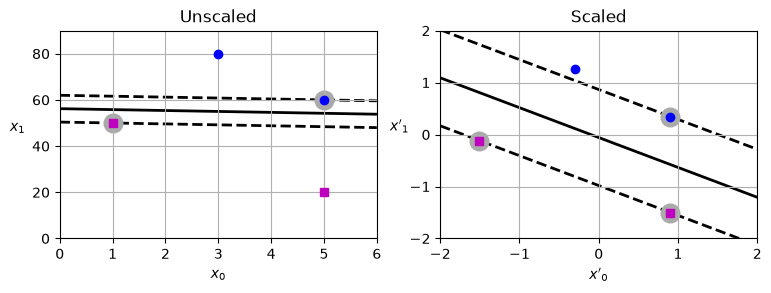

In [3]:

# extra code – this cell generates and saves Figure 5–2

from sklearn.preprocessing import StandardScaler

Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100).fit(Xs, ys)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf_scaled = SVC(kernel="linear", C=100).fit(X_scaled, ys)

plt.figure(figsize=(9, 2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$")
plt.ylabel("$x_1$    ", rotation=0)
plt.title("Unscaled")
plt.axis([0, 6, 0, 90])
plt.grid()

plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf_scaled, -2, 2)
plt.xlabel("$x'_0$")
plt.ylabel("$x'_1$  ", rotation=0)
plt.title("Scaled")
plt.axis([-2, 2, -2, 2])
plt.grid()

plt.savefig(r"C:\Users\marco\Downloads\sensitivity_to_feature_scales_plot")
plt.show()


## Clasificación con Margen Blando



Si imponemos estrictamente que todas las instancias deben estar fuera de la calle y en el lado correcto, esto se denomina **clasificación de margen duro** (*hard margin classification*). 

Hay dos problemas principales con este enfoque. Primero, solo funciona si los datos son linealmente separables. Segundo, es sensible a los valores atípicos (*outliers*).



La Figura 5-3 muestra el conjunto de datos Iris con un único valor atípico adicional: a la izquierda, es imposible encontrar un margen duro; a la derecha, el límite de decisión termina siendo muy diferente al que vimos en la Figura 5-1 sin el valor atípico, y probablemente no generalice tan bien.



**Figura 5-3. Sensibilidad del margen duro a los valores atípicos**


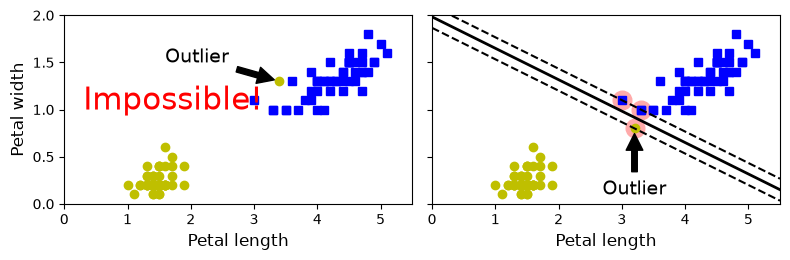

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC

# 1. Cargar el dataset Iris (Petal length, Petal width)
iris = datasets.load_iris()
X = iris.data[:, (2, 3)]  # Petal length, Petal width
y = iris.target

# Filtrar solo Setosa y Versicolor
setosa_or_versicolor = y < 2
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# 2. Definir los outliers
X_out1 = np.concatenate([X, [[3.4, 1.3]]], axis=0)
y_out1 = np.concatenate([y, [0]], axis=0)

X_out2 = np.concatenate([X, [[3.2, 0.8]]], axis=0)
y_out2 = np.concatenate([y, [0]], axis=0)

# Configurar figura
fig, axes = plt.subplots(ncols=2, figsize=(8, 2.7), sharey=True)

# ----------------- Gráfica Izquierda (Imposible) -----------------
plt.sca(axes[0])
plt.plot(
    X_out1[:, 0][y_out1 == 1],
    X_out1[:, 1][y_out1 == 1],
    "bs",
    label="Iris versicolor",
)
plt.plot(
    X_out1[:, 0][y_out1 == 0],
    X_out1[:, 1][y_out1 == 0],
    "yo",
    label="Iris setosa",
)
plt.text(0.3, 1.0, "Impossible!", fontsize=22, color="red")
plt.annotate(
    "Outlier",
    xy=(3.4, 1.3),
    xytext=(2.1, 1.5),
    ha="center",
    arrowprops=dict(facecolor="black", shrink=0.1),
    fontsize=14,
)
plt.axis([0, 5.5, 0, 2])
plt.xlabel("Petal length", fontsize=12)
plt.ylabel("Petal width", fontsize=12)

# ----------------- Gráfica Derecha (Con SVM) -----------------
svm_clf2 = SVC(kernel="linear", C=10**10)
svm_clf2.fit(X_out2, y_out2)

plt.sca(axes[1])
plt.plot(
    X_out2[:, 0][y_out2 == 1],
    X_out2[:, 1][y_out2 == 1],
    "bs",
)
plt.plot(
    X_out2[:, 0][y_out2 == 0],
    X_out2[:, 1][y_out2 == 0],
    "yo",
)

# Dibujar frontera de decisión y márgenes
w = svm_clf2.coef_[0]
b = svm_clf2.intercept_[0]
x0 = np.linspace(0, 5.5, 200)
decision_boundary = -w[0] / w[1] * x0 - b / w[1]
margin1 = decision_boundary + 1 / w[1]
margin2 = decision_boundary - 1 / w[1]

plt.plot(x0, decision_boundary, "k-", linewidth=2)
plt.plot(x0, margin1, "k--", linewidth=1.5)
plt.plot(x0, margin2, "k--", linewidth=1.5)

# Anotación y resaltado de vectores de soporte
plt.scatter(
    svm_clf2.support_vectors_[:, 0],
    svm_clf2.support_vectors_[:, 1],
    s=180,
    facecolors="#FFAAAA",
)
plt.annotate(
    "Outlier",
    xy=(3.2, 0.8),
    xytext=(3.2, 0.1),
    ha="center",
    arrowprops=dict(facecolor="black", shrink=0.1),
    fontsize=14,
)
plt.axis([0, 5.5, 0, 2])
plt.xlabel("Petal length", fontsize=12)

plt.tight_layout()

# 3. Guardar la imagen correctamente con la extensión .png
plt.savefig(
    r"C:\Users\marco\Downloads\sensitivity_to_outliers_plot.png", dpi=300
)
plt.show()


Para evitar estos problemas, se utiliza un modelo más flexible. 

El objetivo es encontrar un buen equilibrio entre mantener la calle lo más ancha posible y limitar las **violaciones del margen** (es decir, instancias que terminan en medio de la calle o incluso en el lado incorrecto). Esto se denomina **clasificación de margen blando** (*soft margin classification*).



Al crear un modelo SVM usando Scikit-Learn, podemos especificar varios hiperparámetros. **C** es uno de ellos. 

Si lo establecemos en un valor bajo, obtenemos el modelo de la izquierda en la Figura 5-4. Con un valor alto, obtenemos el modelo de la derecha. 

Las violaciones del margen son malas, pero suele ser mejor tener pocas. Sin embargo, en este caso, el modelo de la izquierda tiene muchas violaciones del margen, pero probablemente generalizará mejor.



**Figura 5-4. Margen amplio (izquierda) versus menos violaciones del margen (derecha)**



ValueError: Found input variables with inconsistent numbers of samples: [4, 100]

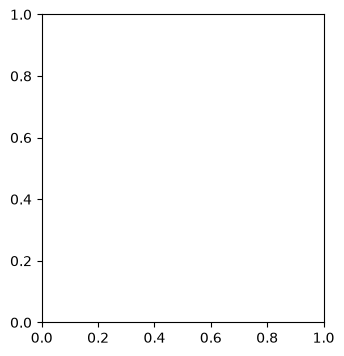

In [11]:
# Código para generar la Figura 5-4
# Entrenar dos SVM con diferentes valores de C
C_values = [0.01, 100]
plt.figure(figsize=(8, 4))
for idx, C in enumerate(C_values):
    plt.subplot(1, 2, idx+1)
    svm_clf = LinearSVC(C=C, loss="hinge", random_state=42, dual=False)
    svm_clf.fit(X_scaled, y)
    plot_svm_decision_boundary(svm_clf, -2, 2, -2, 2)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.Paired)
    plt.xlabel("Largo del pétalo (escalado)")
    plt.ylabel("Ancho del pétalo (escalado)")
    plt.title(f"C = {C}")
plt.savefig(r"C:\Users\marco\Downloads\svm_c_values.png")    
plt.show()


**CONSEJO**
Si tu modelo SVM está sobreajustando, puedes intentar regularizarlo reduciendo el valor de **C**.



## Código de Entrenamiento con Scikit-Learn

El siguiente código de Scikit-Learn carga el conjunto de datos Iris, escala las características y entrena un modelo SVM lineal (usando la clase `LinearSVC` con `C=1` y la función de pérdida *hinge*) para detectar flores de Iris virginica:



In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # largo y ancho del pétalo
y = (iris["target"] == 2).astype(np.float64)  # Iris virginica

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42, dual=False)),
])

svm_clf.fit(X, y)


El modelo resultante se representa a la izquierda en la Figura 5-4. 

Luego, como es habitual, puedes usar el modelo para hacer predicciones:



In [ ]:
>>> svm_clf.predict([[5.5, 1.7]])
array([1.])


**NOTA**
A diferencia de los clasificadores de Regresión Logística, los clasificadores SVM no generan probabilidades para cada clase.



# Alternativas a `LinearSVC`



En lugar de usar la clase `LinearSVC`, podríamos usar la clase `SVC` con un kernel lineal. Al crear el modelo `SVC`, escribiríamos `SVC(kernel="linear", C=1)`. O podríamos usar la clase `SGDClassifier` con `SGDClassifier(loss="hinge", alpha=1/(m*C))`. 

Esta aplicación de Descenso de Gradiente Estocástico regularizado (ver Capítulo 4) entrena un clasificador SVM lineal. 

No converge tan rápido como la clase `LinearSVC`, pero puede ser útil para manejar tareas de clasificación en línea o conjuntos de datos enormes que no caben en la memoria (entrenamiento *out-of-core*).



**CONSEJO**
La clase `LinearSVC` regulariza el término de sesgo (*bias*), por lo que debes centrar el conjunto de entrenamiento primero restando su media. 

Esto es automático si escalas los datos usando `StandardScaler`. También asegúrate de establecer el hiperparámetro `loss` en `"hinge"`, ya que no es el valor predeterminado. 

Finalmente, para un mejor rendimiento, debes establecer el hiperparámetro `dual` en `False`, a menos que haya más características que instancias de entrenamiento (discutiremos la dualidad más adelante en el capítulo).